<a href="https://colab.research.google.com/github/kurotiyamitali-dotcom/Python-basic-project/blob/main/task27.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.datasets import make_moons
import pandas as pd

X, y = make_moons(n_samples=500, noise=0.05, random_state=42)

df = pd.DataFrame(X, columns=['Feature1', 'Feature2'])

print(df.head(10))
print(df.shape)

   Feature1  Feature2
0  0.830586 -0.447733
1  0.701678  0.816918
2  1.022080 -0.492571
3 -0.316765  0.953438
4  0.293226  1.057185
5  1.254903 -0.483435
6  1.053851 -0.442690
7  0.031380  1.053012
8  0.620545  0.713096
9  1.787657 -0.142959
(500, 2)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

print(X_scaled[:5])

[[ 0.37512461 -1.40367864]
 [ 0.22681458  1.13562771]
 [ 0.59544154 -1.49371022]
 [-0.94491835  1.40974769]
 [-0.24311512  1.61806199]]


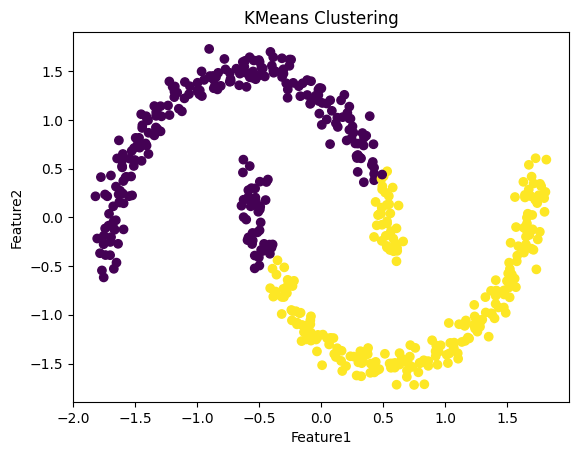

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

kmeans = KMeans(n_clusters=2, random_state=42)
df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=df['kmeans_cluster'])
plt.title('KMeans Clustering')
plt.xlabel('Feature1')
plt.ylabel('Feature2')
plt.show()

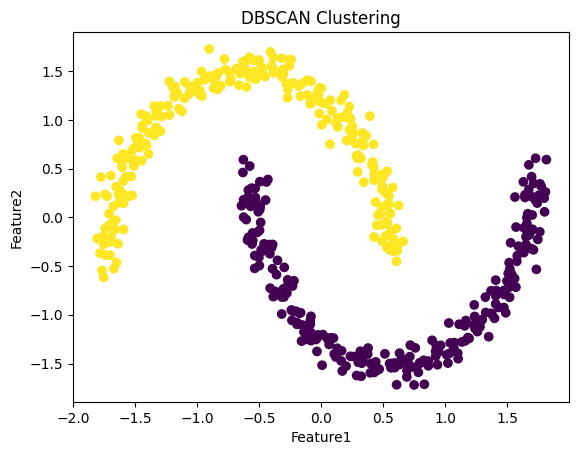

In [ ]:
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

dbscan = DBSCAN(eps=0.3, min_samples=5)
df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=df['dbscan_cluster'])
plt.title('DBSCAN Clustering')
plt.xlabel('Feature1')
plt.ylabel('Feature2')
plt.show()

In [ ]:
from sklearn.cluster import DBSCAN
import pandas as pd

results = []

for eps in [0.2, 0.3, 0.4, 0.5]:
    labels = DBSCAN(eps=eps, min_samples=5).fit_predict(X_scaled)
    clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise = list(labels).count(-1)
    results.append([eps, clusters, noise])

results_df = pd.DataFrame(results, columns=['eps', 'number of clusters', 'number of noise points'])

print(results_df)

   eps  number of clusters  number of noise points
0  0.2                   2                       0
1  0.3                   2                       0
2  0.4                   2                       0
3  0.5                   2                       0


In [ ]:
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

X, y = make_blobs(
    n_samples=500,
    n_features=6,
    centers=4,
    cluster_std=1.5,
    random_state=42
)

X_scaled = StandardScaler().fit_transform(X)

In [ ]:
from sklearn.decomposition import PCA
import pandas as pd

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['label'] = y

print(pca.explained_variance_ratio_)

[0.64327878 0.21039738]


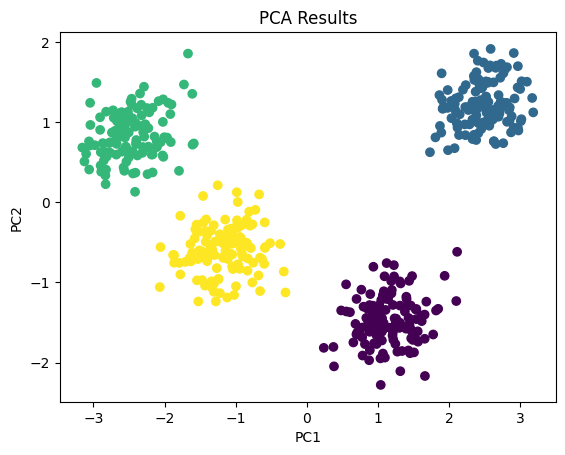

The explained variance ratio shows how much information is retained by the two principal components.


In [ ]:
import matplotlib.pyplot as plt

plt.scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['label'])
plt.title('PCA Results')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

print("The explained variance ratio shows how much information is retained by the two principal components.")

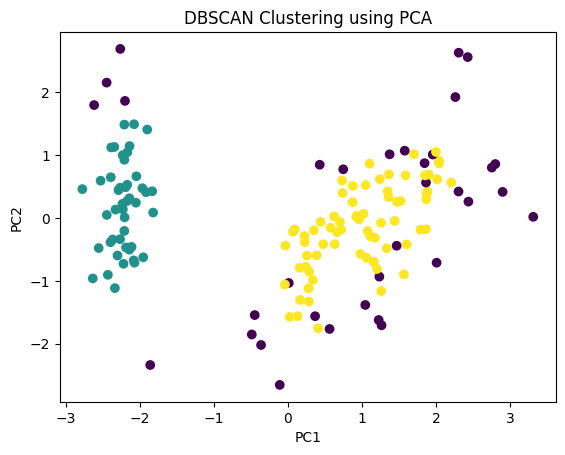

In [ ]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd

iris = load_iris()
X = iris.data

X_scaled = StandardScaler().fit_transform(X)

dbscan = DBSCAN(eps=0.5, min_samples=5)
labels = dbscan.fit_predict(X_scaled)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['label'] = labels

plt.scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['label'])
plt.title('DBSCAN Clustering using PCA')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()